In [1]:
import numpy as np
import pandas as pd

In [2]:
# assumptions
mortgage_balance = 410000
mortgage_rate = 0.03625
monthly_rate = (1+mortgage_rate)**(1/12)-1
rent = 3900
mortgage_payment = 2050
escrow = 750
hoa_payment = 420
condo_value = 800000
sell_costs = 0.04


def calculate_remaining_principal(current_loan_amount, periods_remaining, payment_per_period, interest_rate_per_period):
    """
    Calculate the remaining principal amount on a loan after a specified number of periods.
    
    Args:
    current_loan_amount (float): The current balance of the loan
    periods_remaining (int): Number of payment periods remaining
    payment_per_period (float): The fixed payment amount per period
    interest_rate_per_period (float): The interest rate per period (as a decimal)
    
    Returns:
    float: The remaining principal amount after the specified number of periods
    """
    remaining_principal = []
    remaining_principal.append(current_loan_amount)
    for _ in range(periods_remaining):
        interest = remaining_principal[-1] * interest_rate_per_period
        principal_payment = payment_per_period - interest
        remaining_principal.append(remaining_principal[-1] - principal_payment)
    
    return remaining_principal  # Ensure the result is not negative



Break-even at year: None


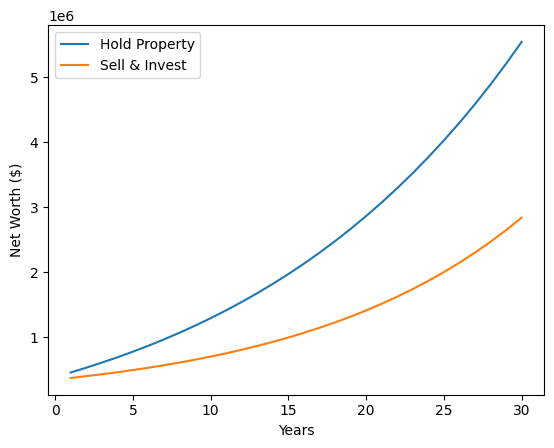

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def compare_property_vs_stock(
    initial_value,
    mortgage_balance,
    mortgage_rate,
    mortgage_term_years,
    rental_income_monthly,
    vacancy_rate,
    property_tax_rate,
    insurance_annual,
    hoa_monthly,
    maintenance_rate,
    repairs_annual,
    selling_cost_rate,
    property_appreciation_rate,
    stock_return_rate,
    horizon_years
):
    """
    Compare net worth trajectory of holding a rental property versus selling it and investing proceeds.

    Parameters:
    initial_value (float): Current market value of the property.
    mortgage_balance (float): Outstanding mortgage principal.
    mortgage_rate (float): Annual mortgage interest rate (decimal, e.g., 0.04 for 4%).
    mortgage_term_years (int): Original mortgage term in years.
    rental_income_monthly (float): Gross monthly rental income.
    vacancy_rate (float): Expected vacancy rate (decimal, e.g., 0.05 for 5%).
    property_tax_rate (float): Annual property tax rate (decimal).
    insurance_annual (float): Annual insurance cost.
    hoa_monthly (float): Monthly HOA fees.
    maintenance_rate (float): Annual maintenance cost as a fraction of property value (decimal).
    repairs_annual (float): Annual repairs cost.
    selling_cost_rate (float): Fraction of sale price paid in selling costs (e.g., 0.06 for 6%).
    property_appreciation_rate (float): Expected annual property value growth rate (decimal).
    stock_return_rate (float): Expected annual return rate of stock investments (decimal).
    horizon_years (int): Time horizon for analysis in years.

    Returns:
    years (list of int): List of years from 1 to horizon_years.
    net_worth_hold (list of float): Net worth each year if holding property (equity + reinvested cash flow).
    net_worth_sell (list of float): Net worth each year if selling and investing proceeds.
    break_even (int or None): Year when selling & investing overtakes holding, or None if never.
    """
    # Monthly parameters
    months = horizon_years * 12
    r_month = stock_return_rate / 12
    m_rate = mortgage_rate / 12
    m_months = mortgage_term_years * 12
    
    # Mortgage payment calculation
    if mortgage_balance > 0 and m_rate > 0:
        payment = mortgage_balance * m_rate / (1 - (1 + m_rate) ** -m_months)
    else:
        payment = 0
    
    fund_balance = 0
    equity = []
    fund_values = []
    sell_investment = []
    
    # Initial net sale proceeds
    initial_net_sale = initial_value - mortgage_balance - selling_cost_rate * initial_value
    
    # Starting mortgage balance
    bal = mortgage_balance
    
    for month in range(1, months + 1):
        # Property value growth
        prop_val = initial_value * (1 + property_appreciation_rate) ** (month / 12)
        
        # Mortgage amortization
        if bal > 0:
            interest = bal * m_rate
            principal = payment - interest
            bal = max(bal - principal, 0)
        else:
            payment = 0
        
        # Monthly expenses
        tax = prop_val * property_tax_rate / 12
        maintenance = prop_val * maintenance_rate / 12
        repairs = repairs_annual / 12
        insurance = insurance_annual / 12
        
        # Net rental cash flow
        net_rent = rental_income_monthly * (1 - vacancy_rate)
        net_cf = net_rent - (payment + hoa_monthly + tax + maintenance + repairs + insurance)
        
        # Reinvestment of net cash flow
        fund_balance = fund_balance * (1 + r_month) + net_cf
        
        # Record at year-end
        if month % 12 == 0:
            year = month // 12
            equity.append(prop_val - bal)
            fund_values.append(fund_balance)
            sell_investment.append(initial_net_sale * (1 + r_month) ** (12 * year))
    
    years = list(range(1, horizon_years + 1))
    net_worth_hold = [e + f for e, f in zip(equity, fund_values)]
    net_worth_sell = sell_investment
    
    # Identify break-even year
    break_even = None
    for y, hold_val, sell_val in zip(years, net_worth_hold, net_worth_sell):
        if sell_val > hold_val:
            break_even = y
            break
    
    return years, net_worth_hold, net_worth_sell, break_even

# # Sample usage and plotting (adjust params as needed)
# if __name__ == "__main__":
#     params = {
#         "initial_value": 500000,
#         "mortgage_balance": 350000,
#         "mortgage_rate": 0.04,
#         "mortgage_term_years": 30,
#         "rental_income_monthly": 2000,
#         "vacancy_rate": 0.05,
#         "property_tax_rate": 0.012,
#         "insurance_annual": 1200,
#         "hoa_monthly": 300,
#         "maintenance_rate": 0.01,
#         "repairs_annual": 1000,
#         "selling_cost_rate": 0.06,
#         "property_appreciation_rate": 0.02,
#         "stock_return_rate": 0.07,
#         "horizon_years": 30
#     }
    
#     years, keep, sell, breakeven = compare_property_vs_stock(**params)
#     print(f"Break-even at year: {breakeven}")
#     plt.plot(years, keep, label="Hold Property")
#     plt.plot(years, sell, label="Sell & Invest")
#     if breakeven:
#         plt.axvline(breakeven, linestyle='--', label=f"Break-even: Year {breakeven}")
#     plt.xlabel('Years')
#     plt.ylabel('Net Worth ($)')
#     plt.legend()
#     plt.show()


# Sample usage and plotting (adjust params as needed)
if __name__ == "__main__":
    params = {
        "initial_value": 800000,
        "mortgage_balance": 410000,
        "mortgage_rate": 0.0369,
        "mortgage_term_years": 26,
        "rental_income_monthly": 3900,
        "vacancy_rate": 0.00,
        "property_tax_rate": 11.58 / 1000,
        "insurance_annual": 2500,
        "hoa_monthly": 420,
        "maintenance_rate": 0.005,
        "repairs_annual": 5000,
        "selling_cost_rate": 0.05,
        "property_appreciation_rate": 0.08,
        "stock_return_rate": 0.07,
        "horizon_years": 30
    }
    
    years, keep, sell, breakeven = compare_property_vs_stock(**params)
    print(f"Break-even at year: {breakeven}")
    plt.plot(years, keep, label="Hold Property")
    plt.plot(years, sell, label="Sell & Invest")
    if breakeven:
        plt.axvline(breakeven, linestyle='--', label=f"Break-even: Year {breakeven}")
    plt.xlabel('Years')
    plt.ylabel('Net Worth ($)')
    plt.legend()
    plt.show()
